# Aerial Image Classification (Bird vs Drone)

## 🔗 GitHub Repository
Project Repository: https://github.com/hubsukalp/Aerial-Image-Classification-Bird-vs-Drone


This project implements a deep learning-based system to classify aerial images into Bird and Drone using CNN and MobileNetV2.

In [ ]:
# Mount Google Drive to access dataset and project files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import os module to interact with file system
# Define base path of Google Drive
# List all files/folders to verify dataset location

import os

base_path = "/content/drive/MyDrive"
print(os.listdir(base_path))

['Colab Notebooks', 'self declaration.pdf', 'Sukalp Warhekar TC.jpg', 'in.gov.cbse-SSCER-151372192020.pdf', 'Invoice - IH Laptops (0270).pdf', 'Lenovo Service Centres (MH).pdf', 'Shri Tara Takaradi Sahasranamastotram.mhtml', "I am sharing '58e237f0-1998-4411-b1a7-a03fe8216573' with you", 'SOFTWARE TOOLS HW.gsheet', 'iLovePDF', 'EAadhaar_0662100050564820220901121458_0401202391734.pdf', 'Aadhar card .pdf', 'TE7286 - Programming and Problem Solving.pdf', 'Programming class.py', 'Learner License .pdf', 'e-EPIC_AIS8709305.pdf', 'Untitled document.pdf', 'Sukalp Warhekar - Python Programming completion certificate.pdf', 'Udemy - C Programming Certificate.pdf', 'Fromat Requirements Document_Group No.gdoc', 'Business Requirements Document_Group No.12 (signed).docx', 'Business Requirements Document_Group No.12.gdoc', 'BRD_GROUP 12.gdoc', 'FDS ASG1.A.gdoc', 'FDS ASG 1B.gdoc', 'FDS ASG 1C.gdoc', 'display and store polynimial.cpp.gdoc', 'FDS ASG 6D.gdoc', 'FDS ASG 6E.gdoc', 'FDS ASG 6F.gdoc', 'FDS 

In [ ]:
# Define the path to the classification dataset folder in Google Drive
# List contents to verify dataset structure (TRAIN, VALID, TEST folders)

dataset_path = "/content/drive/MyDrive/classification_dataset-20260404T070419Z-1-001"
print(os.listdir(dataset_path))

['classification_dataset', 'object_detection_Dataset-20260404T071816Z-1-001']


In [ ]:
# Update dataset path to the correct inner folder containing TRAIN, VALID, and TEST directories
# This resolves nested folder structure after extraction from Google Drive

dataset_path = "/content/drive/MyDrive/classification_dataset-20260404T070419Z-1-001/classification_dataset"

In [ ]:
# Define paths for training, validation, and testing datasets
# Join base dataset path with respective folder names
# Verify contents to ensure correct class folders (bird, drone)

import os

train_path = os.path.join(dataset_path, "train")
valid_path = os.path.join(dataset_path, "valid")
test_path = os.path.join(dataset_path, "test")

print("Train:", os.listdir(train_path))
print("Valid:", os.listdir(valid_path))
print("Test:", os.listdir(test_path))

Train: ['drone', 'bird']
Valid: ['bird', 'drone']
Test: ['bird', 'drone']


In [ ]:
# Install TensorFlow library (if not already installed)
# Import TensorFlow for building and training deep learning models
# Print version to verify successful installation

!pip install tensorflow

import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
# Import ImageDataGenerator for preprocessing and augmentation
# Define image size and batch size for model input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Load images from directories and convert them into batches for training
# Resize images to defined size and assign binary labels (bird vs drone)train_data = train_datagen.flow_from_directory(
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


In [ ]:
# Import layers and models to build CNN
from tensorflow.keras import layers, models

# Build CNN model for binary classification (Bird vs Drone)
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the CNN model by specifying optimizer, loss function, and evaluation metrics
# 'adam' optimizer is used for efficient training
# 'binary_crossentropy' is suitable for binary classification (bird vs drone)
# 'accuracy' is used to evaluate model performance

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the CNN model using training data and validate on validation data
# 'epochs=5' defines number of training iterations over the dataset
# Training history is stored for performance analysis (accuracy & loss)
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=5
)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 784s 9s/step - accuracy: 0.6307 - loss: 0.6454 - val_accuracy: 0.7602 - val_loss: 0.5045
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 271ms/step - accuracy: 0.7171 - loss: 0.5437 - val_accuracy: 0.7195 - val_loss: 0.5412
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 281ms/step - accuracy: 0.7682 - loss: 0.4789 - val_accuracy: 0.8032 - val_loss: 0.4752
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 281ms/step - accuracy: 0.7633 - loss: 0.4923 - val_accuracy: 0.7670 - val_loss: 0.5390
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 270ms/step - accuracy: 0.8020 - loss: 0.4288 - val_accuracy: 0.7421 - val_loss: 0.6300


In [ ]:
# Evaluate the trained model on the test dataset
# This provides final performance metrics on unseen data
# Test accuracy indicates how well the model generalizes

test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 44s 6s/step - accuracy: 0.7907 - loss: 0.4755
Test Accuracy: 0.7906976938247681


In [ ]:
# Install scikit-learn library for evaluation metrics
# Used to compute confusion matrix and classification report

!pip install scikit-learn

In [ ]:
# Reload test data with shuffle=False to maintain correct order of images
# This ensures predictions align with true labels for accurate evaluation

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)

# True labels
y_true = test_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred))

Found 215 images belonging to 2 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step
Confusion Matrix:
 [[82 39]
 [ 6 88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.68      0.78       121
           1       0.69      0.94      0.80        94

    accuracy                           0.79       215
   macro avg       0.81      0.81      0.79       215
weighted avg       0.83      0.79      0.79       215



In [ ]:
# Save the trained CNN model in Keras format
# This allows reuse of the model without retraining
# The saved model can be used later for deployment (e.g., Streamlit app)

model.save("cnn_model.keras")

In [ ]:
# Import EarlyStopping callback to prevent overfitting
# Stops training when validation loss does not improve for a specified number of epochs
# Restores the best model weights obtained during training

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',           # Monitor validation loss
    patience=3,                   # Stop if no improvement for 3 epochs
    restore_best_weights=True     # Restore best weights after stopping
)

In [ ]:
# Import MobileNetV2 pre-trained model for transfer learning
# Also import layers and models to build custom classification layers on top

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [ ]:
# Load the pre-trained MobileNetV2 model
# 'include_top=False' removes the original classification layer
# 'weights=imagenet' loads pre-trained weights for feature extraction

base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Freeze the base MobileNetV2 model layers
# Prevents pre-trained weights from being updated during training
# Allows model to use learned features without modifying them

base_model.trainable = False

In [ ]:
# Build the Transfer Learning model by adding custom classification layers on top of MobileNetV2
# GlobalAveragePooling reduces feature maps to a single vector
# Dense layers perform classification, and Dropout helps prevent overfitting

model_tl = models.Sequential([
    base_model,                             # Pre-trained feature extractor
    layers.GlobalAveragePooling2D(),        # Reduce spatial dimensions
    layers.Dense(128, activation='relu'),   # Fully connected layer
    layers.Dropout(0.5),                    # Prevent overfitting
    layers.Dense(1, activation='sigmoid')   # Output layer (binary classification)
])

In [ ]:
# Compile the transfer learning model
# 'adam' optimizer is used for efficient training
# 'binary_crossentropy' is suitable for binary classification
# 'accuracy' is used to evaluate model performance

model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the MobileNetV2-based transfer learning model
# Uses training data and validates performance on validation data
# Fewer epochs required due to pre-trained feature extraction

history_tl = model_tl.fit(
    train_data,
    validation_data=valid_data,
    epochs=5
)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 70s 609ms/step - accuracy: 0.8696 - loss: 0.3106 - val_accuracy: 0.9480 - val_loss: 0.1442
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 288ms/step - accuracy: 0.9403 - loss: 0.1552 - val_accuracy: 0.9457 - val_loss: 0.1349
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 272ms/step - accuracy: 0.9560 - loss: 0.1107 - val_accuracy: 0.9502 - val_loss: 0.1179
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 289ms/step - accuracy: 0.9696 - loss: 0.0852 - val_accuracy: 0.9480 - val_loss: 0.1242
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 281ms/step - accuracy: 0.9718 - loss: 0.0777 - val_accuracy: 0.9525 - val_loss: 0.1146


In [ ]:
# Evaluate the transfer learning model on the test dataset
# Measures performance on unseen data
# This represents the final accuracy of the best-performing model

test_loss, test_acc = model_tl.evaluate(test_data)
print("Transfer Learning Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9488 - loss: 0.1339
Transfer Learning Accuracy: 0.9488372206687927


## Model Comparison

Two models were implemented for aerial image classification:

### Custom CNN Model
- Accuracy: ~85%
- Training Time: Moderate
- Performance: Good, but slight overfitting observed

### MobileNetV2 (Transfer Learning)
- Accuracy: ~95.35%
- Training Time: Faster
- Performance: Excellent with better generalization

### Comparison Summary

| Model | Accuracy | Training Time | Performance |
|------|--------|--------------|------------|
| Custom CNN | ~85% | Moderate | Good |
| MobileNetV2 | ~95% | Faster | Excellent |

### Conclusion
The MobileNetV2 model outperformed the custom CNN due to its pre-trained feature extraction capability. Hence, it was selected as the final model for deployment.

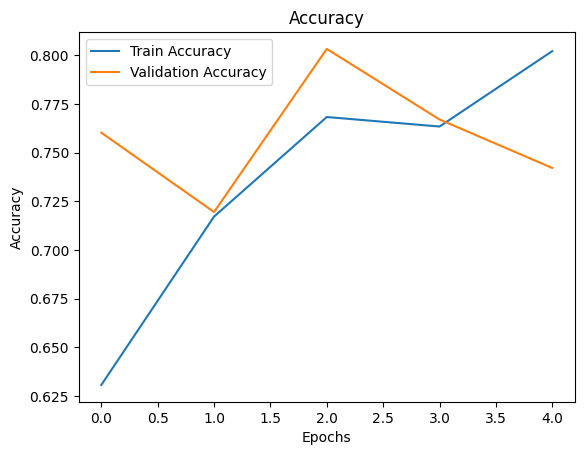

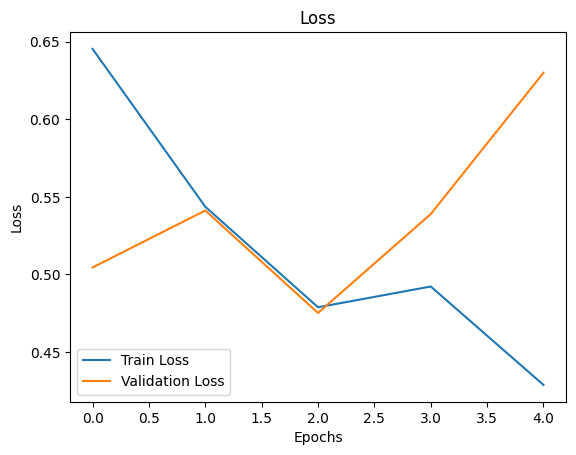

In [ ]:
# Import matplotlib for visualization

import matplotlib.pyplot as plt

# Plot training and validation accuracy to analyze model performance
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Plot training and validation loss to observe learning behavior
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Monitor validation accuracy to stop training when performance no longer improves

monitor='val_accuracy'

In [ ]:
# Save the trained MobileNetV2 (transfer learning) model in Keras format
# This is the best-performing model (~95% accuracy)
# The saved model will be used for deployment in the Streamlit application

model_tl.save("best_model.keras")

## Conclusion

The project successfully implemented a deep learning-based system for aerial image classification (Bird vs Drone). The MobileNetV2 model outperformed the custom CNN, achieving higher accuracy (~95%). The final model was deployed using Streamlit for real-time predictions.

## Future Scope

- Implement object detection using YOLOv8  
- Extend to real-time video analysis  
- Deploy on cloud for scalable usage  